# QuantJourney SDK - Market Data Basics

This notebook demonstrates how to fetch and visualize market data:
- Historical prices (OHLCV)
- Candlestick charts
- Multiple symbols comparison
- Performance visualization

**API:** https://api.quantjourney.cloud

In [11]:
import sys
sys.path.insert(0, '..')

from quantjourney.sdk import QuantJourneyAPI
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "png" 

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# API Key authentication (recommended)
API_KEY = "QJ_live_4fe809e7e0212107ae9d98664f6e4b0c48fdbb2184af72fc41b6c0b849a2cab9"

qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")

✓ Connected to QuantJourney API


## 1. Fetch Historical Prices

In [12]:
# Get AAPL historical prices
response = qj.eod.get_historical_prices(
    symbol="AAPL",
    start_date="2024-01-01",
    end_date="2024-12-31",
    frequency="1d"
)

# Extract data from response (EOD returns data in 'value' key)
prices = response.get('value', response) if isinstance(response, dict) else response

df = pd.DataFrame(prices)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

print(f"Fetched {len(df)} records")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.tail()

Fetched 252 records
Date range: 2024-01-02 to 2024-12-31


,date,open,high,low,close,adjusted_close,volume
247,2024-12-24,255.49,258.21,255.29,258.20,257.0375,23234700
248,2024-12-26,258.19,260.10,257.63,259.02,257.8538,27237100
249,2024-12-27,257.83,258.70,253.06,255.59,254.4392,42355300
250,2024-12-30,252.23,253.50,250.75,252.20,251.0645,35557500
251,2024-12-31,252.44,253.28,249.43,250.42,249.2925,39480700


## 2. Candlestick Chart

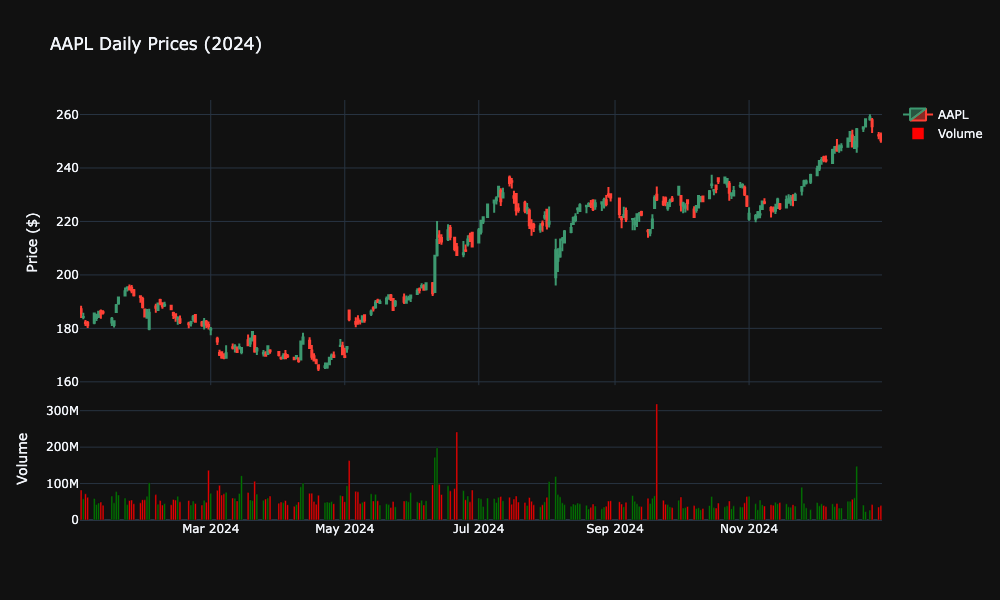

In [13]:
# Create candlestick chart with volume
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=[0.7, 0.3]
)

# Candlestick
fig.add_trace(
    go.Candlestick(
        x=df['date'],
        open=df['open'],
        high=df['high'],
        low=df['low'],
        close=df['close'],
        name='AAPL'
    ),
    row=1, col=1
)

# Volume bars
colors = ['red' if close < open else 'green' 
          for close, open in zip(df['close'], df['open'])]
fig.add_trace(
    go.Bar(x=df['date'], y=df['volume'], marker_color=colors, name='Volume'),
    row=2, col=1
)

fig.update_layout(
    title='AAPL Daily Prices (2024)',
    template='plotly_dark',
    height=600,
    xaxis_rangeslider_visible=False
)
fig.update_yaxes(title_text="Price ($)", row=1, col=1)
fig.update_yaxes(title_text="Volume", row=2, col=1)
fig.show()

## 3. Multi-Stock Comparison

In [14]:
# Fetch multiple stocks
symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
all_prices = {}

for symbol in symbols:
    try:
        response = qj.eod.get_historical_prices(
            symbol=symbol,
            start_date="2024-01-01",
            end_date="2024-12-31"
        )
        # Extract data from response
        prices = response.get('value', response) if isinstance(response, dict) else response
        if prices:
            df_sym = pd.DataFrame(prices)
            df_sym['date'] = pd.to_datetime(df_sym['date'])
            all_prices[symbol] = df_sym.set_index('date')['close']
            print(f"✓ {symbol}: {len(df_sym)} records")
    except Exception as e:
        print(f"✗ {symbol}: {e}")

✓ AAPL: 252 records
✓ MSFT: 252 records
✓ GOOGL: 252 records
✓ AMZN: 252 records
✓ NVDA: 252 records


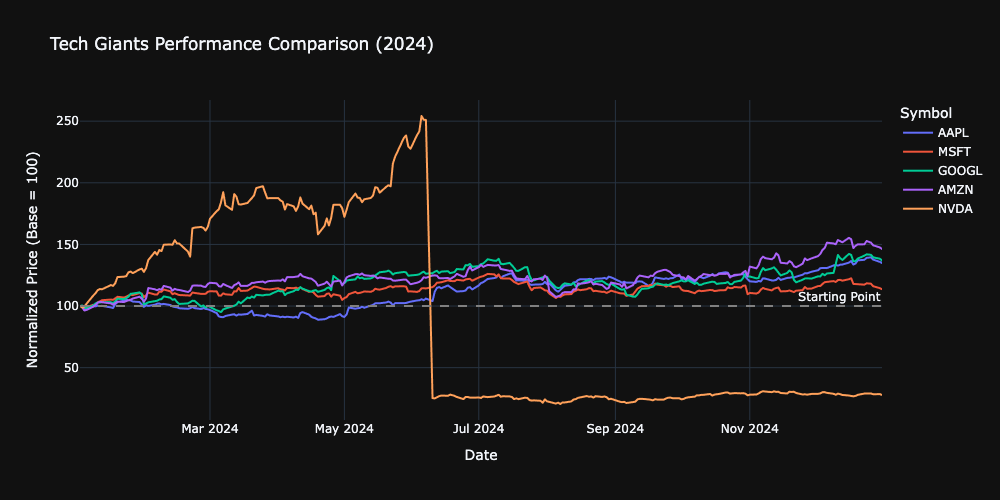

In [15]:
# Normalize to 100 and plot
df_combined = pd.DataFrame(all_prices)
df_normalized = df_combined / df_combined.iloc[0] * 100

fig = px.line(
    df_normalized,
    title='Tech Giants Performance Comparison (2024)',
    template='plotly_dark'
)
fig.update_layout(
    yaxis_title='Normalized Price (Base = 100)',
    xaxis_title='Date',
    legend_title='Symbol',
    height=500
)
fig.add_hline(y=100, line_dash="dash", line_color="gray", annotation_text="Starting Point")
fig.show()

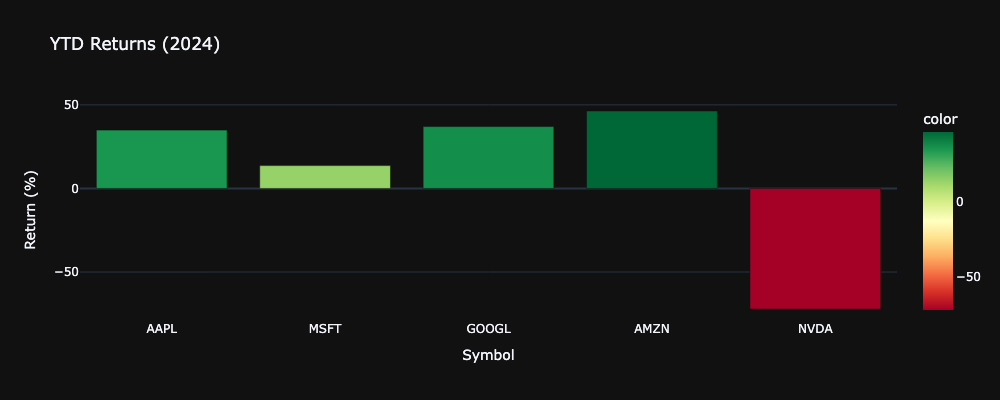


YTD Returns:
  AMZN: +46.3%
  GOOGL: +37.0%
  AAPL: +34.9%
  MSFT: +13.7%
  NVDA: -72.1%


In [16]:
# Returns summary
returns = (df_combined.iloc[-1] / df_combined.iloc[0] - 1) * 100

fig = px.bar(
    x=returns.index,
    y=returns.values,
    color=returns.values,
    color_continuous_scale='RdYlGn',
    title='YTD Returns (2024)',
    template='plotly_dark'
)
fig.update_layout(
    yaxis_title='Return (%)',
    xaxis_title='Symbol',
    showlegend=False,
    height=400
)
fig.show()

print("\nYTD Returns:")
for sym, ret in returns.sort_values(ascending=False).items():
    print(f"  {sym}: {ret:+.1f}%")

## 4. Volatility Comparison

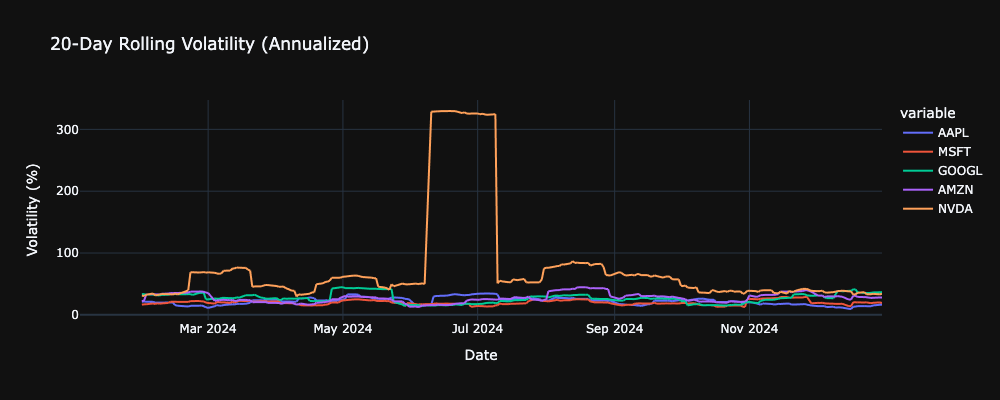

In [17]:
import numpy as np

# Calculate daily returns and rolling volatility
df_returns = df_combined.pct_change().dropna()
df_vol = df_returns.rolling(20).std() * np.sqrt(252) * 100  # Annualized

fig = px.line(
    df_vol,
    title='20-Day Rolling Volatility (Annualized)',
    template='plotly_dark'
)
fig.update_layout(
    yaxis_title='Volatility (%)',
    xaxis_title='Date',
    height=400
)
fig.show()

## 5. Correlation Heatmap

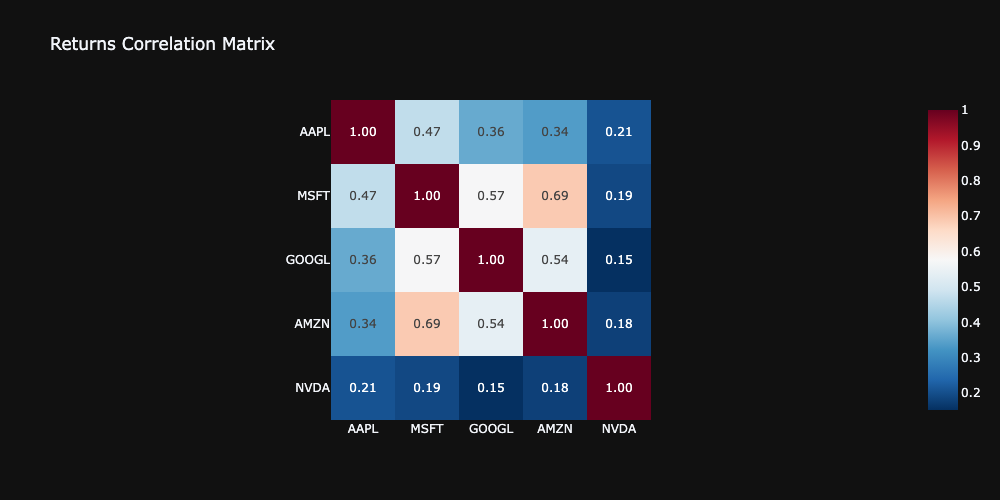

In [18]:
# Correlation matrix
corr = df_returns.corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Returns Correlation Matrix',
    template='plotly_dark'
)
fig.update_layout(height=500)
fig.show()

## Summary

Key methods demonstrated:
- `qj.eod.get_historical_prices()` - OHLCV data
- Candlestick charts with volume
- Performance normalization and comparison
- Rolling volatility calculation
- Correlation analysis